In [1]:
###################################################
import emcee
import numpy as np
import scipy

from astropy.io import fits
from astropy.table import Table
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from functools import partial
import time
from astropy.coordinates import SkyCoord
import astropy.units as u
import pyccl as ccl
import clevar
import numpy as np
from astropy.table import Table
import clmm
from clevar.catalog import ClCatalog, MemCatalog
from clevar.match_metrics import recovery
import matplotlib.pyplot as plt
from clevar.match import MembershipMatch
from clevar.match_metrics import distances
from clevar.match_metrics import scaling
from clevar.match import ProximityMatch
from clevar.match_metrics.recovery import ClCatalogFuncs as r_cf
###################################################

## Selection

### Catalogs

In [2]:
matching_folder = '/sps/lsst/groups/clusters/redmapper_validation_project/cosmoDC2_v1.1.4/extragal/after_matching/v0/'

t_red = Table.read(f"{matching_folder}/c1.fits")
display(t_red)
t_halo = Table.read(f"{matching_folder}/c2.fits")
display(t_halo)

id,ra,dec,z,mass,SkyCoord,mt_self,mt_other,mt_multi_self,mt_multi_other,mt_frac_self,mt_frac_other,mt_cross
,,,,,"deg,deg",,,,,,,
bytes11,float64,float64,float32,float32,SkyCoord,bytes13,bytes13,bytes147,bytes147,float64,float64,bytes13
10,52.520436430812914,-25.717996124671657,0.5135129,190.70665,"52.520436430812914,-25.717996124671657",1162500021323,1162500021323,"417800021323,1162500021323,80500021323,711400021315,1361100021315,205900021323,665600021315,922700021315","417800021323,1162500021323,80500021323,1361100021315,205900021323,665600021315,922700021315,711400021315",0.4155844155844156,0.30094043887147337,1162500021323
18,56.920376528125075,-27.20434071042304,0.5712697,179.12813,"56.920376528125075,-27.20434071042304",549500032315,549500032315,549500032315,549500032315,0.9,0.35064935064935066,549500032315
24,56.99849698116052,-26.7172081871169,1.040338,124.02715,"56.99849698116052,-26.7172081871169",2554900032241,2554900032241,"1212700032259,3011300032241,2554900032241","1212700032259,3011300032241,2554900032241",0.8951048951048951,0.28444444444444444,2554900032241
30,58.56362402841767,-27.429961828331713,0.63518524,167.33603,"58.56362402841767,-27.429961828331713",1275900032300,1275900032300,"1275900032300,6600032300","1275900032300,6600032300",0.96875,0.2767857142857143,1275900032300
71,58.35519782866568,-26.867687128773035,0.44230303,111.9147,"58.35519782866568,-26.867687128773035",564000032338,564000032338,"778100032338,731900032338,243000032347,564000032338,359200032338,161400032338","731900032338,778100032338,243000032347,564000032338,359200032338,161400032338",0.4689655172413793,0.2518518518518518,564000032338
73,57.76575707007693,-28.119101936484828,0.46697217,104.439766,"57.76575707007693,-28.119101936484828",459400032338,459400032338,"2200032331,459400032338,980800032331","2200032331,459400032338,980800032331",0.8449612403100775,0.2780612244897959,459400032338
109,58.509466974185045,-26.989676182075844,0.4413634,103.49396,"58.509466974185045,-26.989676182075844",156700032338,156700032338,"433200032355,156700032338","433200032355,156700032338",0.9166666666666666,0.28672985781990523,156700032338
116,54.494027152041674,-27.896589555863095,1.0629631,76.85877,"54.494027152041674,-27.896589555863095",3080200031235,3080200031235,"3080200031235,2468800031230","3080200031235,2468800031230",0.8586956521739131,0.2791519434628975,3080200031235


id,ra,dec,z,mass,log_mass,m200c,log_m200c,SkyCoord,mt_self,mt_other,mt_multi_self,mt_multi_other,mt_frac_other,mt_frac_self,mt_cross
,,,,,,,,"deg,deg",,,,,,,
bytes21,float64,float64,float64,float64,float64,float64,float64,SkyCoord,bytes6,bytes6,bytes31,bytes31,float64,float64,bytes6
1600020475,50.775875822529436,-27.112584328955446,0.04530489444732666,2.247e+13,13.351613892324458,18901145086557.746,13.276488115798056,"50.775875822529436,-27.112584328955446",--,--,--,--,0.0,0.0,--
2700020475,49.466814189348334,-25.960541211222015,0.04615640640258789,1.633e+13,13.2130360195722,15062094204754.93,13.177885359536557,"49.466814189348334,-25.960541211222015",--,--,--,--,0.0,0.0,--
17200020453,50.16585579512233,-25.259404686564693,0.08653247356414795,2.283e+13,13.358450109677962,20441971397588.734,13.310522776287003,"50.16585579512233,-25.259404686564693",--,--,--,--,0.0,0.0,--
19000020453,49.51865674267036,-26.131426039026245,0.09413313865661621,1.199e+13,13.078863522811979,10668658238016.902,13.028109803073287,"49.51865674267036,-26.131426039026245",--,--,--,--,0.0,0.0,--
19800020453,50.691634217578326,-26.88681304144144,0.08739697933197021,8.412e+13,13.924887877935069,71624983358738.03,13.855064534072003,"50.691634217578326,-26.88681304144144",--,--,--,--,0.0,0.0,--
32800020453,51.49405530538187,-26.309071814426567,0.08795535564422607,1.328e+13,13.123179943904667,10371945197971.832,13.015860213430779,"51.49405530538187,-26.309071814426567",--,--,--,--,0.0,0.0,--
2000020442,51.03054382968504,-25.767733992572435,0.10751283168792725,3.555e+13,13.550864347552649,31256384653340.848,13.494938742848014,"51.03054382968504,-25.767733992572435",--,--,--,--,0.0,0.0,--
32300020442,51.48013416475692,-25.825311694587846,0.10751473903656006,1.339e+13,13.126824099732831,11587427913554.93,13.063987045375406,"51.48013416475692,-25.825311694587846",--,--,--,--,0.0,0.0,--


In [3]:
cl_redmapper_tags = {'id':'cat1_id', 'mass':'cat1_richness', 'z':'cat1_z', 'ra':'cat1_ra','dec':'cat1_dec'}
halo_tags = {'id':'cat2_id', 'mass':'cat2_M200c','z':'cat2_z', 'ra':'cat2_ra','dec':'cat2_dec'}

col = t_halo['mt_cross']

t_halo['mt_cross'] = np.where(col.mask, None, col)
col = t_red['mt_cross']

t_red['mt_cross'] = np.where(col.mask, None, col)

cat_red = ClCatalog(data = t_red, name='cat_red')
cat_halo = ClCatalog(data = t_halo  , name='cat_halo')
print(type(cat_halo['mt_cross'][0]))
display(cat_halo)
display(cat_halo[cat_halo['mt_cross'] is None])

<class 'NoneType'>


id,ra,dec,z,mass,log_mass,m200c,log_m200c,mt_self,mt_other,mt_multi_self,mt_multi_other,mt_frac_other,mt_frac_self,mt_cross
str21,float64,float64,float64,float64,float64,float64,float64,bytes6,bytes6,bytes31,bytes31,float64,float64,object
1600020475,50.775875822529436,-27.112584328955446,0.04530489444732666,2.247e+13,13.351613892324458,18901145086557.746,13.276488115798056,--,--,--,--,0.0,0.0,None
2700020475,49.466814189348334,-25.960541211222015,0.04615640640258789,1.633e+13,13.2130360195722,15062094204754.93,13.177885359536557,--,--,--,--,0.0,0.0,None
17200020453,50.16585579512233,-25.259404686564693,0.08653247356414795,2.283e+13,13.358450109677962,20441971397588.734,13.310522776287003,--,--,--,--,0.0,0.0,None
19000020453,49.51865674267036,-26.131426039026245,0.09413313865661621,1.199e+13,13.078863522811979,10668658238016.902,13.028109803073287,--,--,--,--,0.0,0.0,None
19800020453,50.691634217578326,-26.88681304144144,0.08739697933197021,8.412e+13,13.924887877935069,71624983358738.03,13.855064534072003,--,--,--,--,0.0,0.0,None
32800020453,51.49405530538187,-26.309071814426567,0.08795535564422607,1.328e+13,13.123179943904667,10371945197971.832,13.015860213430779,--,--,--,--,0.0,0.0,None
2000020442,51.03054382968504,-25.767733992572435,0.10751283168792725,3.555e+13,13.550864347552649,31256384653340.848,13.494938742848014,--,--,--,--,0.0,0.0,None
32300020442,51.48013416475692,-25.825311694587846,0.10751473903656006,1.339e+13,13.126824099732831,11587427913554.93,13.063987045375406,--,--,--,--,0.0,0.0,None
33300020442,50.315518939516316,-26.69559169836869,0.108817458152771,3.434e+13,13.53575955305564,29876928281239.438,13.475335944579681,47951,47951,47951,47951,0.6666666666666666,0.5,47951


id,ra,dec,z,mass,log_mass,m200c,log_m200c,SkyCoord,mt_self,mt_other,mt_multi_self,mt_multi_other,mt_frac_other,mt_frac_self,mt_cross
,,,,,,,,"deg,deg",,,,,,,
str21,float64,float64,float64,float64,float64,float64,float64,SkyCoord,bytes6,bytes6,bytes31,bytes31,float64,float64,object
1600020475,50.775875822529436,-27.112584328955446,0.04530489444732666,2.247e+13,13.351613892324458,18901145086557.746,13.276488115798056,"50.775875822529436,-27.112584328955446",--,--,--,--,0.0,0.0,None


## Completeness

In [4]:
from crow import completeness_models
from crow import purity_models

purity_aguena = purity_models.PurityAguena16()
completeness_aguena = completeness_models.CompletenessAguena16()
###################### MCMC ########################
def log_prior(theta):
    """Define the search space for a_n, b_n, a_logm_piv, b_logm_piv."""
    a_n, b_n, a_logm_piv, b_logm_piv = theta
    # Example bounds: adjust based on your specific Aguena16 priors
    if -5.0 < a_n < 20.0 and -5.0 < b_n < 25.0 and 0.0 < a_logm_piv < 26.0 and 0.0 < b_logm_piv < 20.0:
        return 0.0
    return -np.inf

def log_likelihood_gauss(theta, log_mass, z, r, sigma):

    completeness_aguena.parameters["a_n"] = theta[0]
    completeness_aguena.parameters["b_n"] = theta[1]
    completeness_aguena.parameters["a_logm_piv"] = theta[2]
    completeness_aguena.parameters["b_logm_piv"] = theta[3]

    p = completeness_aguena.distribution(log_mass, z)

    if np.any(np.isnan(p)):
        return -np.inf

    chi2 = (r - p)**2 / sigma**2

    return -0.5 * np.sum(chi2 + np.log(2*np.pi*sigma**2))

def log_probability(theta, log_mass, z, r, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_gauss(theta, log_mass, z, r, sigma)

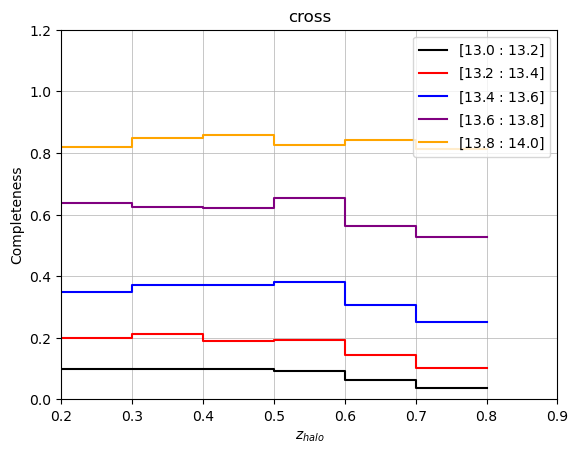

{'recovery': array([[0.09766607, 0.20057637, 0.34975845, 0.63680782, 0.82018927,
        0.91954023, 0.9009901 ],
       [0.09987593, 0.21210084, 0.37047674, 0.624     , 0.84707904,
        0.94485294, 0.936     ],
       [0.096853  , 0.19055609, 0.37128326, 0.62212644, 0.85902503,
        0.95290859, 0.9695122 ],
       [0.09237391, 0.19158361, 0.38043138, 0.65475504, 0.82552693,
        0.9125    , 0.96449704],
       [0.06289988, 0.14307716, 0.30737705, 0.56294058, 0.84321608,
        0.9326087 , 0.95789474],
       [0.03725597, 0.10076149, 0.25211548, 0.52769953, 0.81390977,
        0.93361884, 0.97590361]]), 'edges1': array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]), 'edges2': array([13. , 13.2, 13.4, 13.6, 13.8, 14. , 14.2, 14.4]), 'matched': array([[ 272,  348,  362,  391,  260,  160,   91],
       [ 483,  631,  645,  624,  493,  257,  117],
       [ 674,  795,  949,  866,  652,  344,  159],
       [ 837, 1038, 1217, 1136,  705,  365,  163],
       [ 698,  929, 1125, 1118,  839,  429,

In [5]:
redshift_col = 'z' 
mass_col = 'log_m200c'
#plot style
figx=10
figy=7
matching_selected = 'cross'
# zbins = [0,0.5,0.75,1.0,1.2]
# mbins = np.linspace(13, 14.4, 8)

zbins = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
#mbins = np.linspace(13, 15, 6)
# zbins = [0,0.5,0.75,1.0,1.2]
mbins = np.linspace(12, 15.5, 30)

fig = plt.figure()#figsize=(figx,figy))
info_comp = r_cf.plot(cat_halo, col1=redshift_col, col2=mass_col, bins1=zbins, bins2=mbins, matching_type=matching_selected, legend_format=lambda x: x, lines_kwargs_list = [{'color':'black'}, {'color':'red'}, {'color':'blue'}, {'color':'purple'}, {'color':'orange'}])
info_comp['ax'].set_xlabel('$z_{halo}$')
info_comp['ax'].set_ylabel('Completeness') 
info_comp['ax'].set_ylim(0,1.2)
info_comp['ax'].set_xlim(0.2,0.9) 
info_comp['ax'].set_title(f'{matching_selected}')
plt.show(fig)
# plt.savefig(outpath+'recovery_plot.png', bbox_inches='tight')
plt.close(fig)
print(info_comp['data'])

In [6]:
edges_z = info_comp["data"]["edges1"]
edges_m = info_comp["data"]["edges2"]
recovery_matrix = info_comp["data"]["recovery"]
n_match = info_comp["data"]["matched"]
n_total = info_comp["data"]["counts"]


z_list = []
for i in range(len(edges_z) - 1):
    z_list.append((edges_z[i] + edges_z[i+1]) / 2.0)

m_list = []
for j in range(len(edges_m) - 1):
    m_list.append((edges_m[j] + edges_m[j+1]) / 2.0)
z_list = np.array(z_list)
m_list = np.array(m_list)
mcmc_z = []
mcmc_m = []
mcmc_rec = []
mcmc_n_total = []
mcmc_n_match = []
for i in range(len(z_list)):        # Loop over redshift bins
    for j in range(len(m_list)):    # Loop over mass bins
        mcmc_z.append(z_list[i])
        mcmc_m.append(m_list[j])
        mcmc_rec.append(recovery_matrix[i, j])
        mcmc_n_total.append(n_total[i, j])
        mcmc_n_match.append(n_match[i, j])
# Convert to numpy arrays for speed in the likelihood function
sigma_mcmc = np.std(mcmc_rec)
mcmc_z = np.array(mcmc_z)
mcmc_m = np.array(mcmc_m)
mcmc_rec = np.array(mcmc_rec)
mcmc_n_total = np.array(mcmc_n_total)
mcmc_n_match = np.array(mcmc_n_match)

print(f"Total data points for MCMC: {len(mcmc_rec)}")
print(mcmc_rec, mcmc_z, mcmc_m, mcmc_n_total, mcmc_n_match, sigma_mcmc)

Total data points for MCMC: 42
[0.09766607 0.20057637 0.34975845 0.63680782 0.82018927 0.91954023
 0.9009901  0.09987593 0.21210084 0.37047674 0.624      0.84707904
 0.94485294 0.936      0.096853   0.19055609 0.37128326 0.62212644
 0.85902503 0.95290859 0.9695122  0.09237391 0.19158361 0.38043138
 0.65475504 0.82552693 0.9125     0.96449704 0.06289988 0.14307716
 0.30737705 0.56294058 0.84321608 0.9326087  0.95789474 0.03725597
 0.10076149 0.25211548 0.52769953 0.81390977 0.93361884 0.97590361] [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.35 0.35 0.35 0.35 0.35 0.35 0.35
 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.55 0.55 0.55 0.55 0.55 0.55 0.55
 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.75 0.75 0.75 0.75 0.75 0.75 0.75] [13.1 13.3 13.5 13.7 13.9 14.1 14.3 13.1 13.3 13.5 13.7 13.9 14.1 14.3
 13.1 13.3 13.5 13.7 13.9 14.1 14.3 13.1 13.3 13.5 13.7 13.9 14.1 14.3
 13.1 13.3 13.5 13.7 13.9 14.1 14.3 13.1 13.3 13.5 13.7 13.9 14.1 14.3] [ 2785  1735  1035   614   317   174   101  4836  2975  1741  1000   58

In [7]:
best_fit_c = []
n_params = 4
n_walkers = 50
n_steps = 200000

# Initial guess (center of the ball)
initial_guess = np.array([1.26, 0.38, 11.31, 0.20]) 
pos = initial_guess + 1e-4 * np.random.randn(n_walkers, n_params)

sampler = emcee.EnsembleSampler(
    n_walkers, n_params, log_probability,
    args=(mcmc_m, mcmc_z, mcmc_rec, sigma_mcmc)
)

print("Running MCMC...")
sampler.run_mcmc(pos, n_steps, progress=True)
# Discard first 500 steps and flatten
flat_samples = sampler.get_chain(discard=20000, thin=15, flat=True)


flat_samples = sampler.get_chain(discard=20000, thin=15, flat=True)
flat_log_prob = sampler.get_log_prob(discard=20000, thin=15, flat=True)

# Index of maximum posterior sample
max_ind = np.argmax(flat_log_prob)

map_params = flat_samples[max_ind]

labels_c = ["a_n", "b_n", "a_logm_piv", "b_logm_piv"]

print("MAP (maximum posterior) parameters:")
for label, val in zip(labels_c, map_params):
    best_fit_c.append(val)
    print(f"{label}: {val:.6f}")

Running MCMC...


100%|██████████| 200000/200000 [02:38<00:00, 1264.44it/s]


MAP (maximum posterior) parameters:
a_n: 0.807785
b_n: 0.971511
a_logm_piv: 13.383534
b_logm_piv: 0.151988


### MOdel versus data

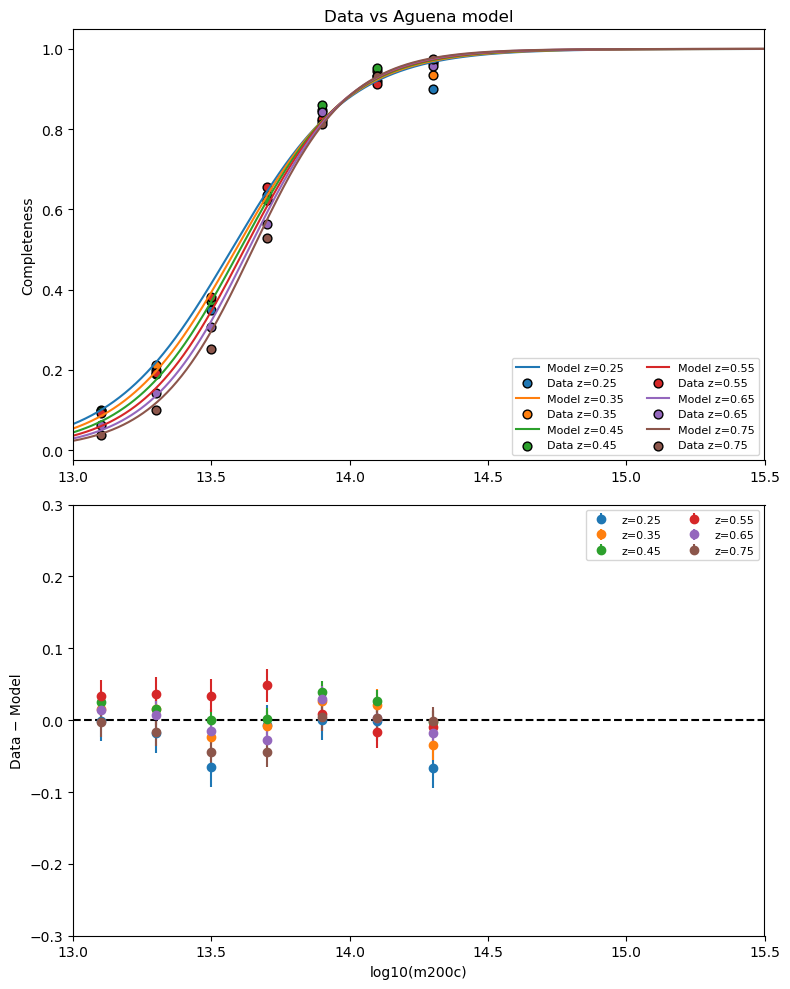

In [8]:
# Set Aguena parameters
completeness_aguena.parameters["a_n"]       = best_fit_c[0]
completeness_aguena.parameters["b_n"]       = best_fit_c[1]
completeness_aguena.parameters["a_logm_piv"] = best_fit_c[2]
completeness_aguena.parameters["b_logm_piv"] = best_fit_c[3]

log_mass_plot = np.linspace(13, 15.5, 1000)

# Create figure with 2 subplots
plt.figure(figsize=(8,10))

# ===== TOP: data vs model =====
plt.subplot(2,1,1)
for i, z in enumerate(z_list):
    model_curve = completeness_aguena.distribution(
        log_mass_plot,
        np.full_like(log_mass_plot, z)
    )
    plt.plot(log_mass_plot, model_curve, label=f"Model z={z:.2f}")
    plt.scatter(m_list, recovery_matrix[i, :], color='C'+str(i), edgecolor='k', s=40, label=f"Data z={z:.2f}")

plt.ylabel("Completeness")
plt.xlim(13,15.5)
plt.title("Data vs Aguena model")
plt.legend(fontsize=8, ncol=2)

# ===== BOTTOM: residuals =====
plt.subplot(2,1,2)
for i, z in enumerate(z_list):
    model_at_bins = completeness_aguena.distribution(
        m_list,
        np.full(len(m_list), z)
    )
    residual = recovery_matrix[i, :] - model_at_bins

    # Empirical scatter per bin as error
    sigma = np.std(residual)

    plt.errorbar(m_list, residual,
                 yerr=sigma,
                 fmt='o',
                 color='C'+str(i),
                 label=f"z={z:.2f}")

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("log10(m200c)")
plt.ylabel("Data − Model")
plt.xlim(13,15.5)
plt.ylim(-0.3, 0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## Purity

In [9]:
from crow import purity_models

purity_aguena = purity_models.PurityAguena16()
###################### MCMC ########################
def log_prior(theta):
    """Define the search space for a_n, b_n, a_logm_piv, b_logm_piv."""
    a_n, b_n, a_logm_piv, b_logm_piv = theta
    # Example bounds: adjust based on your specific Aguena16 priors
    if -5.0 < a_n < 20.0 and -5.0 < b_n < 25.0 and 0.0 < a_logm_piv < 26.0 and 0.0 < b_logm_piv < 20.0:
        return 0.0
    return -np.inf

def log_likelihood_gauss_pur(theta, log_mass_proxy, z, r, sigma):

    purity_aguena.parameters["a_n"] = theta[0]
    purity_aguena.parameters["b_n"] = theta[1]
    purity_aguena.parameters["a_logm_piv"] = theta[2]
    purity_aguena.parameters["b_logm_piv"] = theta[3]

    p = purity_aguena.distribution(log_mass_proxy, z)

    if np.any(np.isnan(p)):
        return -np.inf

    chi2 = (r - p)**2 / sigma**2

    return -0.5 * np.sum(chi2 + np.log(2*np.pi*sigma**2))

def log_probability_pur(theta, log_mass_proxy, z, r, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_gauss_pur(theta, log_mass_proxy, z, r, sigma)

id,ra,dec,z,mass,mt_self,mt_other,mt_multi_self,mt_multi_other,mt_frac_self,mt_frac_other,mt_cross
str11,float64,float64,float32,float32,bytes13,bytes13,bytes147,bytes147,float64,float64,object
10,52.520436430812914,-25.717996124671657,0.5135129,190.70665,1162500021323,1162500021323,"417800021323,1162500021323,80500021323,711400021315,1361100021315,205900021323,665600021315,922700021315","417800021323,1162500021323,80500021323,1361100021315,205900021323,665600021315,922700021315,711400021315",0.4155844155844156,0.30094043887147337,1162500021323
18,56.920376528125075,-27.20434071042304,0.5712697,179.12813,549500032315,549500032315,549500032315,549500032315,0.9,0.35064935064935066,549500032315
24,56.99849698116052,-26.7172081871169,1.040338,124.02715,2554900032241,2554900032241,"1212700032259,3011300032241,2554900032241","1212700032259,3011300032241,2554900032241",0.8951048951048951,0.28444444444444444,2554900032241
30,58.56362402841767,-27.429961828331713,0.63518524,167.33603,1275900032300,1275900032300,"1275900032300,6600032300","1275900032300,6600032300",0.96875,0.2767857142857143,1275900032300
71,58.35519782866568,-26.867687128773035,0.44230303,111.9147,564000032338,564000032338,"778100032338,731900032338,243000032347,564000032338,359200032338,161400032338","731900032338,778100032338,243000032347,564000032338,359200032338,161400032338",0.4689655172413793,0.2518518518518518,564000032338
73,57.76575707007693,-28.119101936484828,0.46697217,104.439766,459400032338,459400032338,"2200032331,459400032338,980800032331","2200032331,459400032338,980800032331",0.8449612403100775,0.2780612244897959,459400032338
109,58.509466974185045,-26.989676182075844,0.4413634,103.49396,156700032338,156700032338,"433200032355,156700032338","433200032355,156700032338",0.9166666666666666,0.28672985781990523,156700032338
116,54.494027152041674,-27.896589555863095,1.0629631,76.85877,3080200031235,3080200031235,"3080200031235,2468800031230","3080200031235,2468800031230",0.8586956521739131,0.2791519434628975,3080200031235
133,58.137368555958155,-27.199784884537003,1.037697,75.89771,2067100032241,2067100032241,"1539400032241,980000032235,2412900032235,2067100032241,1231200032230","1539400032241,980000032235,2412900032235,2067100032241,1231200032230",0.8863636363636364,0.29213483146067415,2067100032241


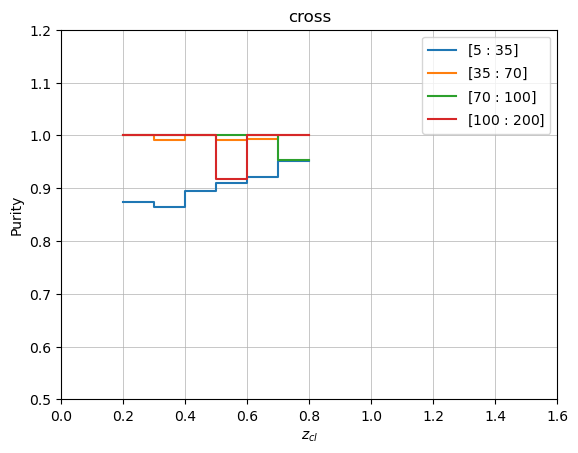

{'recovery': array([[0.87365466, 1.        , 1.        , 1.        ],
       [0.86408567, 0.99038462, 1.        , 1.        ],
       [0.89443883, 1.        , 1.        , 1.        ],
       [0.90899865, 0.99180328, 1.        , 0.91666667],
       [0.92159049, 0.99346405, 1.        , 1.        ],
       [0.95052331, 1.        , 0.95238095, 1.        ]]), 'edges1': array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]), 'edges2': array([  5,  35,  70, 100, 200]), 'matched': array([[1867,   73,   14,    6],
       [3147,  103,   13,    6],
       [4423,  137,   17,   17],
       [5374,  121,   19,   11],
       [4960,  152,   31,   14],
       [4995,  139,   20,    7]]), 'counts': array([[2137,   73,   14,    6],
       [3642,  104,   13,    6],
       [4945,  137,   17,   17],
       [5912,  122,   19,   12],
       [5382,  153,   31,   14],
       [5255,  139,   21,    7]])}
{'data': {'recovery': array([[0.87365466, 1.        , 1.        , 1.        ],
       [0.86408567, 0.99038462, 1.        , 1

In [16]:
redshift_cluster_col = "z"
#print(np.min(c2['zp']))
richness_cluster_col = "mass"
#rbins = np.linspace(np.log10(20), np.log10(200), 4)
rbins = np.array([5, 35, 70, 100, 200])
#zbins = np.array([0.3, 0.5, 0.75, 1.0])
#mbins = np.logspace(14, 15, 5)
display(cat_red)
fig = plt.figure()
info_pur = r_cf.plot(cat_red, col1=redshift_cluster_col, col2=richness_cluster_col, bins1=zbins, bins2=rbins, matching_type=matching_selected)
info_pur['ax'].set_xlabel('$z_{cl}$')
info_pur['ax'].set_ylabel('Purity') 
info_pur['ax'].set_ylim(0.5,1.2)
info_pur['ax'].set_xlim(0.0,1.6) 
info_pur['ax'].set_title(matching_selected)
plt.show(fig)
plt.close(fig)
print(info_pur["data"])


print(info_pur)
print(np.mean(info_pur['data']['recovery']))

In [18]:
edges_z = info_pur["data"]["edges1"]
edges_p = info_pur["data"]["edges2"]
recovery_matrix = info_pur["data"]["recovery"]
n_match = info_pur["data"]["matched"]
n_total = info_pur["data"]["counts"]


z_list = []
for i in range(len(edges_z) - 1):
    z_list.append((edges_z[i] + edges_z[i+1]) / 2.0)

proxy_list = []
for j in range(len(edges_p) - 1):
    proxy_list.append((edges_p[j] + edges_p[j+1]) / 2.0)
z_list = np.array(z_list)
proxy_list = np.array(proxy_list)
mcmc_z = []
mcmc_p = []
mcmc_rec = []
mcmc_n_total = []
mcmc_n_match = []
for i in range(len(z_list)):        # Loop over redshift bins
    for j in range(len(proxy_list)):    # Loop over mass bins
        mcmc_z.append(z_list[i])
        mcmc_p.append(proxy_list[j])
        mcmc_rec.append(recovery_matrix[i, j])
        mcmc_n_total.append(n_total[i, j])
        mcmc_n_match.append(n_match[i, j])
# Convert to numpy arrays for speed in the likelihood function
sigma_mcmc = np.std(mcmc_rec)
mcmc_z = np.array(mcmc_z)
mcmc_p = np.array(mcmc_p)
mcmc_rec = np.array(mcmc_rec)
mcmc_n_total = np.array(mcmc_n_total)
mcmc_n_match = np.array(mcmc_n_match)

print(f"Total data points for MCMC: {len(mcmc_rec)}")
print(mcmc_rec, mcmc_z, mcmc_p, mcmc_n_total, mcmc_n_match, sigma_mcmc)

Total data points for MCMC: 24
[0.87365466 1.         1.         1.         0.86408567 0.99038462
 1.         1.         0.89443883 1.         1.         1.
 0.90899865 0.99180328 1.         0.91666667 0.92159049 0.99346405
 1.         1.         0.95052331 1.         0.95238095 1.        ] [0.25 0.25 0.25 0.25 0.35 0.35 0.35 0.35 0.45 0.45 0.45 0.45 0.55 0.55
 0.55 0.55 0.65 0.65 0.65 0.65 0.75 0.75 0.75 0.75] [ 20.   52.5  85.  150.   20.   52.5  85.  150.   20.   52.5  85.  150.
  20.   52.5  85.  150.   20.   52.5  85.  150.   20.   52.5  85.  150. ] [2137   73   14    6 3642  104   13    6 4945  137   17   17 5912  122
   19   12 5382  153   31   14 5255  139   21    7] [1867   73   14    6 3147  103   13    6 4423  137   17   17 5374  121
   19   11 4960  152   31   14 4995  139   20    7] 0.04515248201394045


In [19]:
best_fit_p = []
n_params = 4
n_walkers = 50
n_steps = 100000

# Initial guess (center of the ball)
initial_guess = np.array([3.9, -0.3, 1.31, 0.40]) 
pos = initial_guess + 1e-4 * np.random.randn(n_walkers, n_params)

sampler = emcee.EnsembleSampler(
    n_walkers, n_params, log_probability_pur,
    args=(mcmc_p, mcmc_z, mcmc_rec, sigma_mcmc)
)

print("Running MCMC...")
sampler.run_mcmc(pos, n_steps, progress=True)
# Discard first 500 steps and flatten
flat_samples = sampler.get_chain(discard=20000, thin=15, flat=True)


flat_samples = sampler.get_chain(discard=20000, thin=15, flat=True)
flat_log_prob = sampler.get_log_prob(discard=20000, thin=15, flat=True)

# Index of maximum posterior sample
max_ind = np.argmax(flat_log_prob)

map_params = flat_samples[max_ind]

labels_p = ["a_n", "b_n", "a_logm_piv", "b_logm_piv"]

print("MAP (maximum posterior) parameters:")
for label, val in zip(labels_p, map_params):
    best_fit_p.append(val)
    print(f"{label}: {val:.6f}")

Running MCMC...


100%|██████████| 100000/100000 [01:15<00:00, 1325.78it/s]

MAP (maximum posterior) parameters:
a_n: -0.784269
b_n: 3.137344
a_logm_piv: 25.345177
b_logm_piv: 0.359044


In [ ]:
# Set Aguena parameters
purity_aguena.parameters["a_n"]       = best_fit_p[0]
purity_aguena.parameters["b_n"]       = best_fit_p[1]
purity_aguena.parameters["a_logm_piv"] = best_fit_p[2]
purity_aguena.parameters["b_logm_piv"] = best_fit_p[3]

log_proxy_plot = np.linspace(1, 3, 1000)

# Create figure with 2 subplots
plt.figure(figsize=(8,10))

# ===== TOP: data vs model =====
plt.subplot(2,1,1)
for i, z in enumerate(z_list):
    model_curve = purity_aguena.distribution(
        log_proxy_plot,
        np.full_like(log_proxy_plot, z)
    )
    plt.plot(log_proxy_plot, model_curve, label=f"Model z={z:.2f}")
    plt.scatter(np.log10(proxy_list), recovery_matrix[i, :], color='C'+str(i), edgecolor='k', s=40, label=f"Data z={z:.2f}")

plt.ylabel("Purity")
plt.title("Data vs Aguena model")
plt.legend(fontsize=8, ncol=2)

# ===== BOTTOM: residuals =====
plt.subplot(2,1,2)
for i, z in enumerate(z_list):
    model_at_bins = purity_aguena.distribution(
        proxy_list,
        np.full(len(proxy_list), z)
    )
    residual = recovery_matrix[i, :] - model_at_bins

    # Empirical scatter per bin as error
    sigma = np.std(residual)

    plt.errorbar(proxy_list, residual,
                 yerr=sigma,
                 fmt='o',
                 color='C'+str(i),
                 label=f"z={z:.2f}")

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("log10(m200c)")
plt.ylabel("Data − Model")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

###############################################################
# 1) Two–parameter completeness function in MASS ONLY
###############################################################

def f_purity_param_2(log10m, log10_mc, nc):
    x = nc * np.log(10) * (log10m - log10_mc)
    return np.exp(x) / (1.0 + np.exp(x))


###############################################################
# 2) Extract binned data from info_comp
###############################################################

edges_z = info_pur["data"]["edges1"]
edges_p = info_pur["data"]["edges2"]
recovery_matrix = info_pur["data"]["recovery"]

# Bin centers
z_list = [(edges_z[i] + edges_z[i+1]) / 2.0 for i in range(len(edges_z)-1)]
proxy_list = [(edges_p[j] + edges_p[j+1]) / 2.0 for j in range(len(edges_p)-1)]

z_list = np.array(z_list)
proxy_list = np.array(proxy_list)

nbins_z = len(z_list)
nbins_proxy = len(proxy_list)

###############################################################
# 3) Fit (log10_mc , nc) independently in each redshift bin
###############################################################

arr_log10_mc = np.zeros(nbins_z)
arr_nc = np.zeros(nbins_z)

plt.figure(figsize=(8,6))

colors = ["black","red","blue","purple","green","brown"]

for i in range(nbins_z):

    ydata = recovery_matrix[i, :]

    # Curve fit in mass direction
    popt, pcov = curve_fit(
        f_purity_param_2,
        xdata=proxy_list,
        ydata=ydata,
        p0=[1.7, 1.0],
        bounds=([1.0, 0.1], [3.0, 10.0])
    )

    arr_log10_mc[i] = popt[0]
    arr_nc[i]       = popt[1]

    print(f"z bin {i} (z={z_list[i]:.3f})  log10_mc={popt[0]:.3f}   nc={popt[1]:.3f}")

    # Plot data and 2-param fit
    x = np.linspace(1, 3, 1000)
    plt.scatter(proxy_list, ydata, label=f"data z={z_list[i]:.2f}")
    plt.plot(x,
             f_purity_param_2(x, popt[0], popt[1]))
             #color=colors[i])
    print(ydata)
plt.xlabel("log10(n200)")
plt.ylabel("Purity")
plt.title("2–parameter fits in each redshift bin")
plt.legend()
plt.show()


###############################################################
# 4) Fit redshift evolution of these parameters
#    Aguena form:
#
#    log10_mc(z) = a_logm_piv + b_logm_piv * (1+z)
#    nc(z)       = a_n + b_n * (1+z)
###############################################################

def lin_z(z, a, b):
    return a + b*(1.0 + z)

# ---- Fit for log10_mc(z)
popt_mc, _ = curve_fit(lin_z, z_list, arr_log10_mc)

# ---- Fit for nc(z)
popt_nc, _ = curve_fit(lin_z, z_list, arr_nc)

a_logm_piv, b_logm_piv = popt_mc
a_n, b_n               = popt_nc

print("\n===== FINAL AGUENA–STYLE PARAMETERS FROM 2-PARAM FIT =====")
print(f"a_logm_piv = {a_logm_piv:.4f}")
print(f"b_logm_piv = {b_logm_piv:.4f}")
print(f"a_n        = {a_n:.4f}")
print(f"b_n        = {b_n:.4f}")


###############################################################
# 5) Reconstruct FULL model using these 4 numbers
###############################################################

purity_aguena_2fit = purity_models.PurityAguena16()
purity_aguena_2fit.parameters["a_n"] = a_n
purity_aguena_2fit.parameters["b_n"] = b_n
purity_aguena_2fit.parameters["a_logm_piv"] = a_logm_piv
purity_aguena_2fit.parameters["b_logm_piv"] = b_logm_piv


###############################################################
# 6) Final comparison plot: DATA vs RECONSTRUCTED MODEL
###############################################################
plt.figure(figsize=(8,6))

log_proxy_plot = np.linspace(1, 3, 1000)
colors = ["black","red","blue","purple","green","brown"]

for i,z in enumerate(z_list):

    # Scatter of binned purity data
    plt.scatter(proxy_list,
                recovery_matrix[i,:],
                color=colors[i % len(colors)],
                edgecolor='k',
                s=40,
                label=f"data z={z:.2f}")

    # Reconstructed 2-param + Aguena model
    plt.plot(log_proxy_plot,
             purity_aguena_2fit.distribution(log_proxy_plot, np.full_like(log_proxy_plot, z)),
             color=colors[i % len(colors)],
             linestyle='--',
             label=f"model z={z:.2f}")

plt.xlabel("log10(n200)")
plt.ylabel("Purity")
plt.title("Purity: 2-param mass fit + Aguena redshift evolution")
plt.ylim(0, 1.2)
plt.legend(fontsize=8, ncol=2)
plt.show()



### FInal comparaison

In [ ]:

log_proxy_plot = np.linspace(1, 3, 1000)

# Create figure with 2 subplots
plt.figure(figsize=(8,10))

# ===== TOP: data vs model =====
plt.subplot(2,1,1)
for i, z in enumerate(z_list):
    # Model curves
    model_curve = purity_aguena.distribution(
        log_proxy_plot,
        np.full_like(log_proxy_plot, z)
    )
    model_curve_2fit = purity_aguena_2fit.distribution(
        log_proxy_plot,
        np.full_like(log_proxy_plot, z)
    )
    
    # Plot curves with different line styles
    plt.plot(log_proxy_plot, model_curve, color=f'C{i}', linestyle='-', label=f"MCMC z={z:.2f}")
    plt.plot(log_proxy_plot, model_curve_2fit, color=f'C{i}', linestyle='--', label=f"2fit z={z:.2f}")
    
    # Scatter points
    plt.scatter(proxy_list, recovery_matrix[i, :], color=f'C{i}', edgecolor='k', s=40, label=f"Data z={z:.2f}")

plt.ylabel("Purity")

plt.title("Data vs Aguena model (MCMC vs 2-fit)")
plt.legend(fontsize=8, ncol=2)

# ===== BOTTOM: residuals =====
plt.subplot(2,1,2)
for i, z in enumerate(z_list):
    # Compute residuals
    model_at_bins = purity_aguena.distribution(
        proxy_list,
        np.full(len(proxy_list), z)
    )
    residual = recovery_matrix[i, :] - model_at_bins
    
    model_at_bins_2fit = purity_aguena_2fit.distribution(
        proxy_list,
        np.full(len(proxy_list), z)
    )
    residual_2fit = recovery_matrix[i, :] - model_at_bins_2fit
    
    # Empirical scatter per bin
    sigma = np.std(residual)
    sigma_2fit = np.std(residual_2fit)
    
    # Plot residuals with different markers for clarity
    plt.errorbar(proxy_list, residual,
                 yerr=sigma,
                 fmt='o',
                 color=f'C{i}',
                 label=f"MCMC z={z:.2f}")
    
    plt.errorbar(proxy_list, residual_2fit,
                 yerr=sigma_2fit,
                 fmt='s',   # square marker for 2-fit
                 color=f'C{i}',
                 label=f"2fit z={z:.2f}")

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("log10(m200c)")
plt.ylabel("Data − Model")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()



In [ ]:
import numpy as np

# Initialize arrays to store relative errors
rel_error_mcmc = []
rel_error_2fit = []

for i, z in enumerate(z_list):
    # model predictions at bin centers
    model_mcmc = purity_aguena.distribution(
        proxy_list,
        np.full(len(proxy_list), z)
    )
    model_2fit = purity_aguena_2fit.distribution(
        proxy_list,
        np.full(len(proxy_list), z)
    )
    
    # Data
    data = recovery_matrix[i, :]
    
    # Avoid division by zero
    mask = data > 0
    
    rel_error_mcmc.extend(np.abs((model_mcmc[mask] - data[mask]) / data[mask]))
    rel_error_2fit.extend(np.abs((model_2fit[mask] - data[mask]) / data[mask]))

# Compute mean relative error
mean_rel_error_mcmc = np.mean(rel_error_mcmc)
mean_rel_error_2fit = np.mean(rel_error_2fit)

print(f"Mean relative error (MCMC fit): {mean_rel_error_mcmc:.3f}")
print(f"Mean relative error (2-param fit): {mean_rel_error_2fit:.3f}")
